<a href="https://colab.research.google.com/github/Kamali1265/ML-Ops-Tasks/blob/main/DAY-5/random_forest_traffic_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h3 style='color:purple' align='center'>Random Forest Python Tutorial</h3>

In [ ]:
import pandas as pd

df = pd.read_csv("traffic_analysis.csv")
df.head()

,vehicle_count,avg_speed,signal_wait_time,peak_hour,congestion_level
0,120,55,20,0,0
1,150,50,25,0,0
2,180,45,30,1,1
3,200,40,35,1,1
4,220,35,40,1,1


In [ ]:
df['congestion_level'].unique()

array([0, 1, 2])

In [ ]:
X = df.drop('congestion_level', axis='columns')
y = df['congestion_level']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   vehicle_count     40 non-null     int64
 1   avg_speed         40 non-null     int64
 2   signal_wait_time  40 non-null     int64
 3   peak_hour         40 non-null     int64
 4   congestion_level  40 non-null     int64
dtypes: int64(5)
memory usage: 1.7 KB


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=20,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=20, random_state=42)

In [ ]:
model.score(X_test, y_test)

1.0

In [ ]:
y_predicted = model.predict(X_test)

y_predicted

array([1, 0, 2, 1, 1, 1, 2, 1])

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_predicted)

cm

array([[1, 0, 0],
       [0, 5, 0],
       [0, 0, 2]])

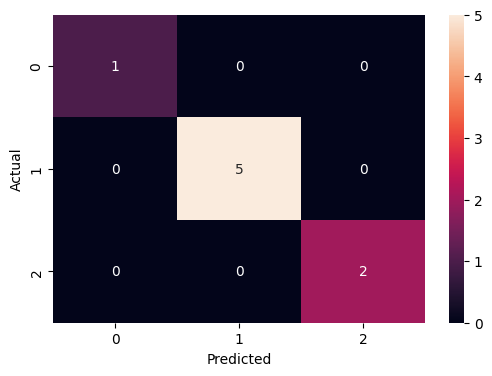

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
model.predict([[250, 30, 45, 1]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([2])